<a href="https://colab.research.google.com/github/Gokul-S777/ioe-ece5801/blob/main/exp5new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       SMART HOSPITAL LIVE MONITORING DASHBOARD

Patients Monitored: 5/25

Patient Monitoring Table


,Patient ID,Respiratory Rate,Systolic BP,Diastolic BP,Blood Glucose,Pulse Rate,Status,Emergency Reason
0,P01,13,120,96,159,81,EMERGENCY,"Diastolic BP, Blood Glucose"
1,P02,20,118,83,142,108,EMERGENCY,"Blood Glucose, Pulse Rate"
2,P03,21,82,100,168,97,EMERGENCY,"Respiratory Rate, Systolic BP, Diastolic BP, B..."
3,P04,24,159,68,122,71,EMERGENCY,"Respiratory Rate, Systolic BP"
4,P05,17,81,61,165,109,EMERGENCY,"Systolic BP, Blood Glucose, Pulse Rate"



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
                    EMERGENCY ALERT
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


,Patient ID,Status,Emergency Reason
0,P01,EMERGENCY,"Diastolic BP, Blood Glucose"
1,P02,EMERGENCY,"Blood Glucose, Pulse Rate"
2,P03,EMERGENCY,"Respiratory Rate, Systolic BP, Diastolic BP, B..."
3,P04,EMERGENCY,"Respiratory Rate, Systolic BP"
4,P05,EMERGENCY,"Systolic BP, Blood Glucose, Pulse Rate"


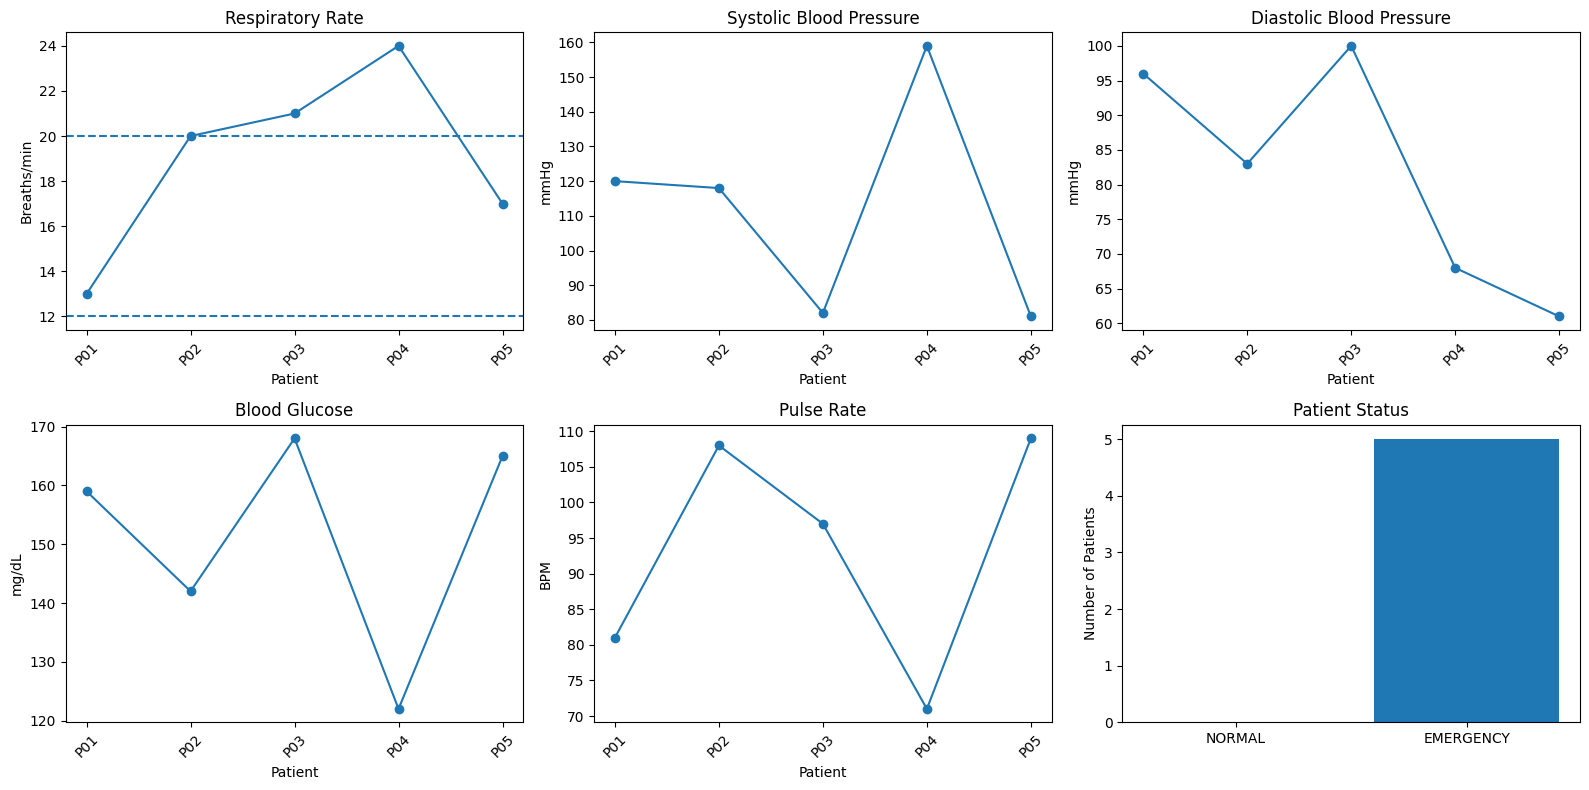

KeyboardInterrupt: 

In [1]:
# ============================================================
# SMART HOSPITAL LIVE PATIENT MONITORING SYSTEM
# Google Colab
# ============================================================

import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

TOTAL_PATIENTS = 25
records = []

print("=" * 70)
print("       SMART HOSPITAL PATIENT MONITORING SYSTEM")
print("=" * 70)

for i in range(1, TOTAL_PATIENTS + 1):

    patient_id = f"P{i:02d}"

    # Generate simulated health parameters
    respiratory_rate = random.randint(10, 24)
    systolic_bp = random.randint(80, 160)
    diastolic_bp = random.randint(50, 100)
    blood_glucose = random.randint(60, 180)
    pulse_rate = random.randint(50, 120)

    # Emergency detection
    emergency_reasons = []

    if respiratory_rate < 12 or respiratory_rate > 20:
        emergency_reasons.append("Respiratory Rate")

    if systolic_bp < 90 or systolic_bp > 140:
        emergency_reasons.append("Systolic BP")

    if diastolic_bp < 60 or diastolic_bp > 90:
        emergency_reasons.append("Diastolic BP")

    if blood_glucose < 70 or blood_glucose > 140:
        emergency_reasons.append("Blood Glucose")

    if pulse_rate < 60 or pulse_rate > 100:
        emergency_reasons.append("Pulse Rate")

    if emergency_reasons:
        status = "EMERGENCY"
        reason = ", ".join(emergency_reasons)
    else:
        status = "NORMAL"
        reason = "None"

    records.append([
        patient_id,
        respiratory_rate,
        systolic_bp,
        diastolic_bp,
        blood_glucose,
        pulse_rate,
        status,
        reason
    ])

    # Create DataFrame
    df = pd.DataFrame(
        records,
        columns=[
            "Patient ID",
            "Respiratory Rate",
            "Systolic BP",
            "Diastolic BP",
            "Blood Glucose",
            "Pulse Rate",
            "Status",
            "Emergency Reason"
        ]
    )

    # Clear previous dashboard
    clear_output(wait=True)

    print("=" * 70)
    print("       SMART HOSPITAL LIVE MONITORING DASHBOARD")
    print("=" * 70)

    print(f"\nPatients Monitored: {i}/{TOTAL_PATIENTS}")

    print("\nPatient Monitoring Table")
    display(df)

    # Emergency Alert
    emergency_df = df[df["Status"] == "EMERGENCY"]

    if not emergency_df.empty:
        print("\n" + "!" * 70)
        print("                    EMERGENCY ALERT")
        print("!" * 70)

        display(
            emergency_df[
                [
                    "Patient ID",
                    "Status",
                    "Emergency Reason"
                ]
            ]
        )
    else:
        print("\nNo emergency cases detected.")

    # --------------------------------------------------------
    # Graphs
    # --------------------------------------------------------

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # Respiratory Rate
    axes[0, 0].plot(
        df["Patient ID"],
        df["Respiratory Rate"],
        marker="o"
    )
    axes[0, 0].axhline(20, linestyle="--")
    axes[0, 0].axhline(12, linestyle="--")
    axes[0, 0].set_title("Respiratory Rate")
    axes[0, 0].set_xlabel("Patient")
    axes[0, 0].set_ylabel("Breaths/min")
    axes[0, 0].tick_params(axis="x", rotation=45)

    # Systolic Blood Pressure
    axes[0, 1].plot(
        df["Patient ID"],
        df["Systolic BP"],
        marker="o"
    )
    axes[0, 1].set_title("Systolic Blood Pressure")
    axes[0, 1].set_xlabel("Patient")
    axes[0, 1].set_ylabel("mmHg")
    axes[0, 1].tick_params(axis="x", rotation=45)

    # Diastolic Blood Pressure
    axes[0, 2].plot(
        df["Patient ID"],
        df["Diastolic BP"],
        marker="o"
    )
    axes[0, 2].set_title("Diastolic Blood Pressure")
    axes[0, 2].set_xlabel("Patient")
    axes[0, 2].set_ylabel("mmHg")
    axes[0, 2].tick_params(axis="x", rotation=45)

    # Blood Glucose
    axes[1, 0].plot(
        df["Patient ID"],
        df["Blood Glucose"],
        marker="o"
    )
    axes[1, 0].set_title("Blood Glucose")
    axes[1, 0].set_xlabel("Patient")
    axes[1, 0].set_ylabel("mg/dL")
    axes[1, 0].tick_params(axis="x", rotation=45)

    # Pulse Rate
    axes[1, 1].plot(
        df["Patient ID"],
        df["Pulse Rate"],
        marker="o"
    )
    axes[1, 1].set_title("Pulse Rate")
    axes[1, 1].set_xlabel("Patient")
    axes[1, 1].set_ylabel("BPM")
    axes[1, 1].tick_params(axis="x", rotation=45)

    # Normal vs Emergency
    normal_count = len(
        df[df["Status"] == "NORMAL"]
    )

    emergency_count = len(
        df[df["Status"] == "EMERGENCY"]
    )

    axes[1, 2].bar(
        ["NORMAL", "EMERGENCY"],
        [normal_count, emergency_count]
    )

    axes[1, 2].set_title("Patient Status")
    axes[1, 2].set_ylabel("Number of Patients")

    plt.tight_layout()
    plt.show()

    # Wait before next patient
    if i < TOTAL_PATIENTS:
        time.sleep(2)

# ============================================================
# FINAL SUMMARY
# ============================================================

normal_count = len(
    df[df["Status"] == "NORMAL"]
)

emergency_count = len(
    df[df["Status"] == "EMERGENCY"]
)

print("\n" + "=" * 70)
print("              FINAL MONITORING SUMMARY")
print("=" * 70)

print("Total Patients Monitored :", TOTAL_PATIENTS)
print("Normal Patients          :", normal_count)
print("Emergency Patients       :", emergency_count)

print("\nEmergency Patient Details")

if emergency_count > 0:

    display(
        df[df["Status"] == "EMERGENCY"][
            [
                "Patient ID",
                "Respiratory Rate",
                "Systolic BP",
                "Diastolic BP",
                "Blood Glucose",
                "Pulse Rate",
                "Emergency Reason"
            ]
        ]
    )

else:
    print("No emergency patients detected.")

print("\nMonitoring Completed Successfully.")
print("=" * 70)